# Практическое задание №4. Задача регрессии на Kaggle с помощью линейной регрессии (light)

**Предсказание критической температуры сверхпроводников**

**Описание**

Явление сверхпроводимости одно из самых удивительных по своей природе, но объяснить его с классической точки зрения невозможно. Данное явление было открыто голландским физиком Хейке Камерлинг-Оннес в 1911 году.

Сверхпроводимость — свойство некоторых веществ и материалов, электрическое сопротивление которых при понижении температуры до определенного уровня падает до нуля. Сверхпроводимость возникает скачком при понижении температуры. Температура при которой возникает скачок называется критической температурой.

Несмотря на то, что сверхпроводимость была открыта больше века назад, многие её свойства плохо изучены, например, связь между сверхпроводимостью и химическими/структурными свойствами материалов.

Вам предлагается разработать алгоритмы машинного обучения, которые позволяют установить связь между химическим составом, различными свойствами сверхпроводниками и их критической температурой.


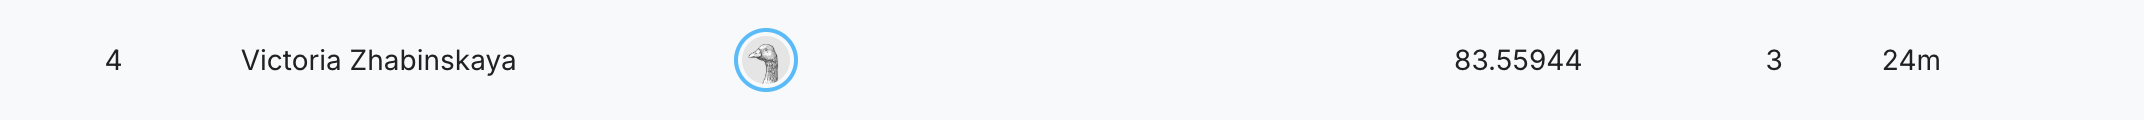

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

import warnings
warnings.filterwarnings('ignore')

!pip install xgboost -q
!pip install lightgbm -q
!pip install catboost -q

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

## Исследование и анализ датасета
## Предобработка данных

In [ ]:
train = pd.read_csv("train.csv")
formula_train = pd.read_csv("formula_train.csv")
test = pd.read_csv("test.csv")
formula_test = pd.read_csv("formula_test.csv")

Посмотрим информацию о таблицах

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               17010 non-null  int64  
 1   mean_atomic_mass                 17010 non-null  float64
 2   wtd_mean_atomic_mass             17010 non-null  float64
 3   gmean_atomic_mass                17010 non-null  float64
 4   wtd_gmean_atomic_mass            17010 non-null  float64
 5   entropy_atomic_mass              17010 non-null  float64
 6   wtd_entropy_atomic_mass          17010 non-null  float64
 7   range_atomic_mass                17010 non-null  float64
 8   wtd_range_atomic_mass            17010 non-null  float64
 9   std_atomic_mass                  17010 non-null  float64
 10  wtd_std_atomic_mass              17010 non-null  float64
 11  mean_fie                         17010 non-null  float64
 12  wtd_mean_fie      

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 81 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               4253 non-null   int64  
 1   mean_atomic_mass                 4253 non-null   float64
 2   wtd_mean_atomic_mass             4253 non-null   float64
 3   gmean_atomic_mass                4253 non-null   float64
 4   wtd_gmean_atomic_mass            4253 non-null   float64
 5   entropy_atomic_mass              4253 non-null   float64
 6   wtd_entropy_atomic_mass          4253 non-null   float64
 7   range_atomic_mass                4253 non-null   float64
 8   wtd_range_atomic_mass            4253 non-null   float64
 9   std_atomic_mass                  4253 non-null   float64
 10  wtd_std_atomic_mass              4253 non-null   float64
 11  mean_fie                         4253 non-null   float64
 12  wtd_mean_fie        

In [ ]:
formula_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Data columns (total 88 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   H              17010 non-null  float64
 1   He             17010 non-null  int64  
 2   Li             17010 non-null  float64
 3   Be             17010 non-null  float64
 4   B              17010 non-null  float64
 5   C              17010 non-null  float64
 6   N              17010 non-null  float64
 7   O              17010 non-null  float64
 8   F              17010 non-null  float64
 9   Ne             17010 non-null  int64  
 10  Na             17010 non-null  float64
 11  Mg             17010 non-null  float64
 12  Al             17010 non-null  float64
 13  Si             17010 non-null  float64
 14  P              17010 non-null  float64
 15  S              17010 non-null  float64
 16  Cl             17010 non-null  float64
 17  Ar             17010 non-null  int64  
 18  K     

In [ ]:
formula_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 87 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   H         4253 non-null   float64
 1   He        4253 non-null   int64  
 2   Li        4253 non-null   float64
 3   Be        4253 non-null   float64
 4   B         4253 non-null   float64
 5   C         4253 non-null   float64
 6   N         4253 non-null   float64
 7   O         4253 non-null   float64
 8   F         4253 non-null   float64
 9   Ne        4253 non-null   int64  
 10  Na        4253 non-null   float64
 11  Mg        4253 non-null   float64
 12  Al        4253 non-null   float64
 13  Si        4253 non-null   float64
 14  P         4253 non-null   float64
 15  S         4253 non-null   float64
 16  Cl        4253 non-null   float64
 17  Ar        4253 non-null   int64  
 18  K         4253 non-null   float64
 19  Ca        4253 non-null   float64
 20  Sc        4253 non-null   floa

У нас есть 4 файла:

train.csv — 17010 строк, 82 столбца (81 признак + critical_temp)

formula_train.csv — 17010 строк, 88 столбцов (элементы + material + critical_temp)

test.csv — 4253 строки, 81 столбец (только признаки)

formula_test.csv — 4253 строки, 87 столбцов (элементы + material)

Соединяем таблицы - то есть объединяем характеристики и химический состав(при этом удалив повторый столбец critical_temp и не нужный material)

In [ ]:
formula_train = formula_train.drop(columns=['critical_temp'])
train_full = pd.concat([train, formula_train], axis=1)
train_full.drop(columns=['material'], inplace=True)

test_full = pd.concat([test, formula_test], axis=1)
test_full.drop(columns=['material'], inplace=True)

Посмотрим на размеры тренировочных и тестовых данных

In [ ]:
print(f"Тренировочные данные: {train_full.shape}")
print(f"Тестовые данные: {test_full.shape}")

Тренировочные данные: (17010, 168)
Тестовые данные: (4253, 167)


In [ ]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Columns: 168 entries, number_of_elements to Rn
dtypes: float64(156), int64(12)
memory usage: 21.8 MB


Проведем анализ целевой переменной

In [ ]:
y = train_full['critical_temp']
y.describe()

count    17010.000000
mean        34.502993
std         34.334793
min          0.000210
25%          5.330000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

Целевая переменная имеет широкий диапазон: от 0.00021 до 185 К. Распределение асимметричное: среднее (34.5) > медиана (20).

Проведем анализ выбросов IQR целевой переменной

In [ ]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y[(y < lower_bound) | (y > upper_bound)]
print(f"  Обнаружено выбросов: {len(outliers)} ({len(outliers)/len(y)*100:.2f}%)")
print(f"  Диапазон выбросов: [{outliers.min():.2f}, {outliers.max():.2f}]")

  Обнаружено выбросов: 1 (0.01%)
  Диапазон выбросов: [185.00, 185.00]


Удалим эти выбросы

In [ ]:
train_clean = train_full[
    (train_full['critical_temp'] >= lower_bound) &
    (train_full['critical_temp'] <= upper_bound)
].copy()

In [ ]:
train_full.isnull().sum().sum()

np.int64(0)

Пропусков нет

Подготовим данные - выделим признаки

In [ ]:
X = train_full.drop(columns=['critical_temp'])
feature_names = X.columns.tolist()

print(f"  Количество признаков: {X.shape[1]}")
print(f"  Количество объектов: {X.shape[0]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


  Количество признаков: 167
  Количество объектов: 17010


**Вывод**: Были проанализированы четыре исходных файла данных, содержащих информацию о сверхпроводящих материалах. Обнаружено, что данные хорошо структурированы, отсутствуют пропущенные значения. Тренировочный набор содержит 17010 образцов, тестовый — 4253. Произведено объединение данных о характеристиках и химическом составе в единые таблицы для тренировочного и тестового наборов. Удалены избыточные и некорректные столбцы. Проведён анализ целевой переменной — критической температуры. Обнаружено асимметричное распределение с одним статистическим выбросом (185 К), который был исключён.

## Подбор признаков, их анализ и оценка важности.

Сортируем признаки по важности с помощью Random Forest

In [ ]:
rf_for_selection = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_for_selection.fit(X_train, y_train)

rf_importances = rf_for_selection.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_importances
}).sort_values('RF_Importance', ascending=False)

print(f"Топ-15 важных признаков по RandomForest:")
for i, row in rf_importance_df.head(15).iterrows():
    print(f"  {i+1:2d}. {row['Feature']:30s} {row['RF_Importance']:.6f}")

Топ-15 важных признаков по RandomForest:
  110. Cu                             0.652755
  101. Ca                             0.056176
  137. Ba                             0.037482
  74. gmean_Valence                  0.021819
  35. wtd_gmean_Density              0.015168
  34. gmean_Density                  0.014076
  75. wtd_gmean_Valence              0.011139
  73. wtd_mean_Valence               0.010414
  111. Zn                             0.007869
  36. entropy_Density                0.007614
  81. wtd_std_Valence                0.007239
  107. Fe                             0.007233
   9. wtd_range_atomic_mass          0.006880
  68. range_ThermalConductivity      0.006832
  63. wtd_mean_ThermalConductivity   0.005824


Тестируем разное количество признаков для нахождения оптимального на тестовой модели

In [ ]:
n_features_options = [10, 20, 30, 40, 50, 75, 100, 150, 'all']
selection_results = []

test_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

for n_features in n_features_options:
    if n_features == 'all':
        selected_features = rf_importance_df['Feature'].tolist()
        n_selected = len(selected_features)
    else:
        selected_features = rf_importance_df.head(n_features)['Feature'].tolist()
        n_selected = n_features

    print(f"{n_selected} признаков ", end=" ")

    X_train_selected = X_train[selected_features]
    X_val_selected = X_test[selected_features]

    test_model.fit(X_train_selected, y_train)
    y_pred = test_model.predict(X_val_selected)
    mse = mean_squared_error(y_test, y_pred)

    selection_results.append({
        'n_features': n_selected,
        'mse': mse
    })

    print(f"MSE: {mse:.2f}")

selection_df = pd.DataFrame(selection_results)
optimal_idx = selection_df['mse'].argmin()
optimal_n_features = selection_df.loc[optimal_idx, 'n_features']
optimal_mse = selection_df.loc[optimal_idx, 'mse']

print(f"\nОптимальное количество признаков: {optimal_n_features}")
print(f" MSE: {optimal_mse:.2f}")


10 признаков  MSE: 125.46
20 признаков  MSE: 116.60
30 признаков  MSE: 115.40
40 признаков  MSE: 112.93
50 признаков  MSE: 111.76
75 признаков  MSE: 110.94
100 признаков  MSE: 110.34
150 признаков  MSE: 110.31
167 признаков  MSE: 110.56

Оптимальное количество признаков: 150
 MSE: 110.31


Увеличение числа признаков улучшает качество до определённого предела.

Теперь отбираем эти 150 признаков

In [ ]:
if optimal_n_features == 'all':
    final_selected_features = rf_importance_df['Feature'].tolist()
else:
    final_selected_features = rf_importance_df.head(optimal_n_features)['Feature'].tolist()

print(f"Выбрано {len(final_selected_features)} признаков из {len(feature_names)}")

Выбрано 150 признаков из 167


**Вывод:** Для выявления наиболее значимых признаков использован Random Forest. Анализ показал, что наибольший вклад в предсказание критической температуры вносит содержание меди (Cu). Другими важными признаками оказались содержание кальция (Ca), бария (Ba), а также статистики валентности и плотности. Определён оптимальный размер признакового пространства — 150 из 167 признаков.


## Обучение нескольких моделей, их сравнение.
## Подбор гиперпараметров.

Подготовим финальные наборы данных

In [ ]:
X_train_final = X_train[final_selected_features]
X_test_final = X_test[final_selected_features]
X_all_final = X[final_selected_features]
test_final = test_full[final_selected_features]

Масштабируем признаки

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_test_final)
X_all_scaled = scaler.fit_transform(X_all_final)
test_scaled = scaler.transform(test_final)

Отбираем модели

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN': KNeighborsRegressor(n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

Теперь подбираем гиперпараметры (GridSearchCV или RandomizedSearchCV)

In [ ]:

param_grids = {
    'Linear Regression': {},

    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },

    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },

    'XGBoost': {
        'n_estimators': [100],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8]
    },

    'LightGBM': {
        'n_estimators': [100],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 50]
    },

    'CatBoost': {
        'iterations': [100],
        'depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'l2_leaf_reg': [3]
    }
}

best_models = {}
results = {}

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

In [ ]:
for model_name, model in models.items():
    print(f"\nМодель {model_name}:")

    if model_name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        best_models[model_name] = model

        cv_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring=mse_scorer, n_jobs=-1
        )

        results[model_name] = {
            'best_score': -cv_scores.mean(),
            'best_params': 'default',
            'cv_std': cv_scores.std()
        }

        print(f"Обучено (без подбора параметров)")
        print(f" CV MSE: {-cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    elif model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']:
        random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[model_name],
        n_iter=5,
        cv=5,
        scoring=mse_scorer,
        n_jobs=-1 if model_name != 'CatBoost' else 1,
        random_state=42,
        verbose=1
        )

        random_search.fit(X_train_scaled, y_train)
        best_models[model_name] = random_search.best_estimator_

        results[model_name] = {
            'best_score': -random_search.best_score_,
            'best_params': random_search.best_params_,
            'cv_std': random_search.cv_results_['std_test_score'][random_search.best_index_]
        }

        print(f"Лучшие параметры: {random_search.best_params_}")
        print(f"CV MSE: {-random_search.best_score_:.4f}")

    else:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            cv=5,
            scoring=mse_scorer,
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train_scaled, y_train)
        best_models[model_name] = grid_search.best_estimator_

        results[model_name] = {
            'best_score': -grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_std': grid_search.cv_results_['std_test_score'][grid_search.best_index_]
        }

        print(f"Лучшие параметры: {grid_search.best_params_}")
        print(f"CV MSE: {-grid_search.best_score_:.4f}")



Модель Linear Regression:
Обучено (без подбора параметров)
 CV MSE: 906.6688 (±862.5916)

Модель Decision Tree:
Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10}
CV MSE: 146.6544

Модель Random Forest:
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры: {'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 20}
CV MSE: 97.4365

Модель Gradient Boosting:
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
CV MSE: 123.7116

Модель KNN:
Лучшие параметры: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
CV MSE: 116.8597

Модель XGBoost:
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
CV MSE: 115.8431

Модель LightGBM:
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры: {'num_leaves': 50, 'n_estimators': 100,

Протестировано восемь различных алгоритмов регрессии. Для каждой модели выполнен подбор гиперпараметров с использованием GridSearchCV (для простых моделей) и RandomizedSearchCV (для сложных ансамблевых алгоритмов). Для Random Forest оптимальными оказались параметры: 150 деревьев, максимальная глубина 20, минимальное разделение выборки 2.



## Выбор лучшей модели и объяснение выбора.

Выбираем лучшую модель по MSE (оцениваем предсказание)

In [ ]:
val_results = {}

for model_name, model in best_models.items():
    y_pred = model.predict(X_val_scaled)

    val_results[model_name] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'CV_MSE': results[model_name]['best_score']
    }

results_df = pd.DataFrame(val_results).T.sort_values('MSE')

print(results_df[['MSE', 'RMSE', 'MAE', 'R2']].round(3))

                       MSE    RMSE     MAE     R2
Random Forest       82.855   9.102   5.208  0.927
KNN                 93.456   9.667   5.258  0.918
LightGBM            95.378   9.766   6.057  0.916
XGBoost            108.002  10.392   6.685  0.905
Gradient Boosting  115.974  10.769   7.152  0.898
Decision Tree      129.212  11.367   6.272  0.886
CatBoost           142.632  11.943   7.913  0.875
Linear Regression  284.308  16.861  12.467  0.750


In [ ]:
best_model_name = results_df.index[0]
best_model = best_models[best_model_name]
best_mse = results_df.loc[best_model_name, 'MSE']
best_r2 = results_df.loc[best_model_name, 'R2']

print(f"Лучшие параметры модели Random Forest:")
print(f"  {results[best_model_name]['best_params']}")

Лучшие параметры модели:
  {'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 20}


Таким образом, Random Forest показал наилучшие метрики:
- Самый низкий MSE (82.86)
- Самый высокий R² (0.927)



## Предсказание на тестовых данных.


Финальное обучение и предсказание - далее сохраняем файл с предсказаниями

In [ ]:
best_model.fit(X_all_scaled, y)
test_predictions = best_model.predict(test_scaled)

print(f"Количество предсказаний: {len(test_predictions)}")
print(f"Минимальное значение: {test_predictions.min():.2f}")
print(f"Максимальное значение: {test_predictions.max():.2f}")
print(f"Среднее значение: {test_predictions.mean():.2f}")

Количество предсказаний: 4253
Минимальное значение: 0.07
Максимальное значение: 133.51
Среднее значение: 34.25


In [ ]:
submission = pd.DataFrame({
    'index': range(len(test_predictions)),
    'critical_temp': test_predictions
})

filename = f'submission.csv'
submission.to_csv(filename, index=False)